In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import discretisedfield
import discretisedfield.tools as dft
import cmasher as cmr

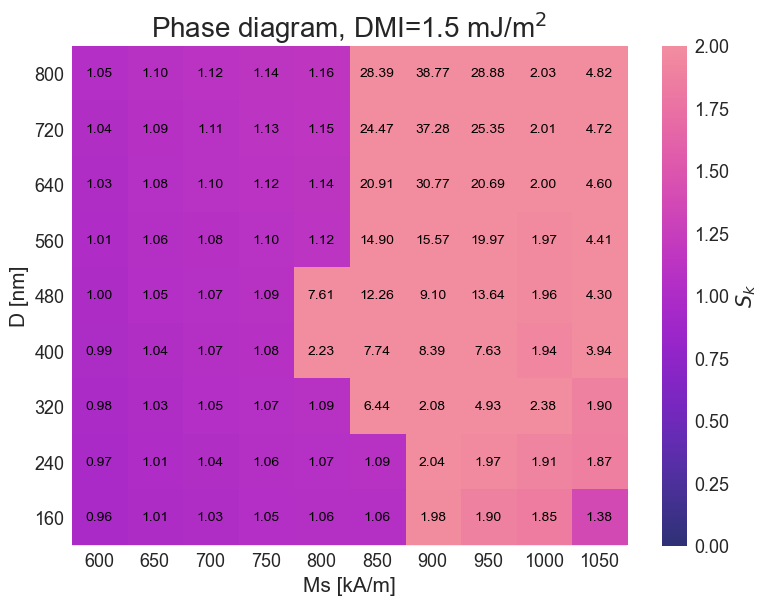

In [77]:
## PLOT THE PHASE DIAGRAM VIA TOPOLOGICAL CHARGE

Ds = range(160, 880, 80)
Mss = range(600, 1100, 50)
dmi = 1.5
T = 0

data = []
for D in Ds:
    value = []
    for Ms in Mss:
        read_field = discretisedfield.Field.from_file(f'../ovf_files/m_D={D}_Ms={Ms}_T=0_dmi={dmi}.ovf')
        topological_charge = dft.topological_charge(read_field.sel(z=0.5e-9), absolute=True)
        value.append(topological_charge)
    data.append(value)

data = np.flip(data, axis=0)
data_matrix = np.array(data)
fig, ax = plt.subplots()
color = cmr.get_sub_cmap('cmr.bubblegum', 0.15, 0.85)
im = ax.imshow(data, cmap=color, interpolation='nearest', vmin=0, vmax=2)

ax.set_xticks(
    range(len(Mss)),
    labels=[f'{Ms}' for Ms in Mss]
)
ax.set_yticks(
    range(len(Ds)),
    labels=[f'{D}' for D in reversed(Ds)]
)

for i in range(len(Ds)):
    for j in range(len(Mss)):
      label = f'{data_matrix[i, j]:.2f}'
      text = ax.text(j, i, label, ha='center', va='center', color='black')

ax.set_title(rf"Phase diagram, DMI={dmi} mJ/m$^2$")
ax.set_ylabel("D [nm]")
ax.set_xlabel("Ms [kA/m]")

fig.colorbar(im, ax=ax, label=r"$S_k$")
fig.tight_layout()
#fig.savefig(f'../images/saf_skyrmion_phase_diagram_sk_dmi={dmi}.png')

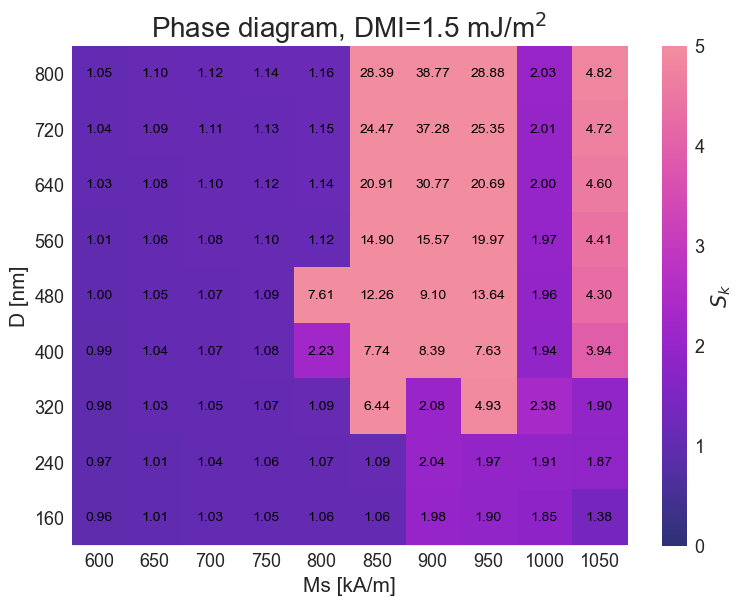

In [78]:
fig, ax = plt.subplots()
color = cmr.get_sub_cmap('cmr.bubblegum', 0.15, 0.85)
im = ax.imshow(data, cmap=color, interpolation='nearest', vmin=0, vmax=5)

ax.set_xticks(
    range(len(Mss)),
    labels=[f'{Ms}' for Ms in Mss]
)
ax.set_yticks(
    range(len(Ds)),
    labels=[f'{D}' for D in reversed(Ds)]
)

for i in range(len(Ds)):
    for j in range(len(Mss)):
      label = f'{data_matrix[i, j]:.2f}'
      text = ax.text(j, i, label, ha='center', va='center', color='black')

ax.set_title(rf"Phase diagram, DMI={dmi} mJ/m$^2$")
ax.set_ylabel("D [nm]")
ax.set_xlabel("Ms [kA/m]")

fig.colorbar(im, ax=ax, label=r"$S_k$")
fig.tight_layout()

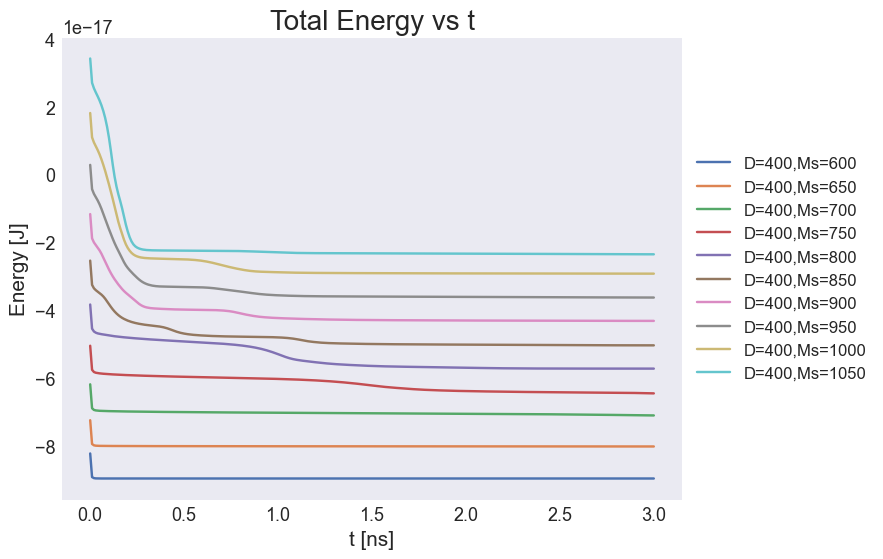

In [95]:
# PLOT ENERGY VS t

dmi = 2
data_path = '../data/'
filename = 'table_D={D}_Ms={Ms}_T={T}_dmi={dmi}.txt'
D = 400
t = np.arange(0,3+0.01,0.01)
for Ms in Mss:
    df = pd.read_table(data_path + filename.format(
        D=D,
        Ms=Ms,
        dmi=dmi,
        T=0
    ))
    E_total = df['E_total (J)']
    plt.plot(t, E_total, label=f'D={D},Ms={Ms}')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.title(r'Total Energy vs t')
plt.ylabel('Energy [J]')
plt.xlabel('t [ns]')
plt.show()

In [71]:
df.columns

Index(['# t (s)', 'mx ()', 'my ()', 'mz ()', 'spinAngle (rad)', 'E_total (J)',
       'E_anis (J)', 'E_demag (J)', 'E_exch (J)', 'E_therm (J)',
       'E_custom (J)'],
      dtype='object')

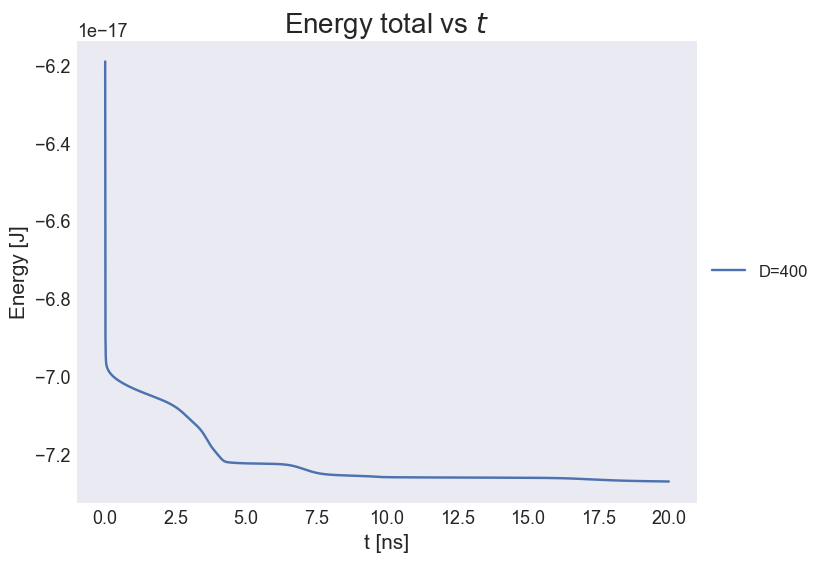

In [99]:
dmi = 2
data_path = '../data/'
filename = 'table_D={D}_Ms={Ms}_T={T}_dmi={dmi}_run.txt'
#t = np.arange(0,20+0.01,0.01)
D = 400
Ms = 700

df = pd.read_table(data_path + filename.format(
    D=D,
    Ms=Ms,
    dmi=dmi,
    T=0
))
t = df['# t (s)']*1e9
E_total = df['E_total (J)']

plt.plot(t, E_total, label=f'D={D}')    
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title(r'Energy total vs $t$')
plt.ylabel('Energy [J]')
plt.xlabel('t [ns]')
plt.show()

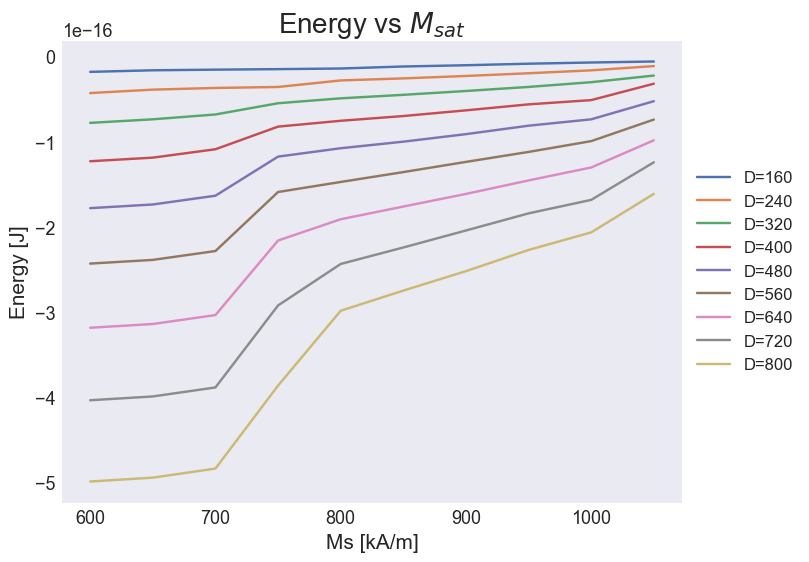

In [14]:
# PLOT ENERGY VS Msat

for D in Ds:
    energies = []
    for Ms in Mss:
        df = pd.read_table(data_path + filename.format(
            D=D,
            Ms=Ms,
            dmi=dmi,
            T=0
        ))
        E_rkky = df['E_anis (J)'].iloc[-1]
        energies.append(E_rkky)
    plt.plot(Mss, energies, label=f'D={D}')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title(r'Energy vs $M_{sat}$')
plt.ylabel('Energy [J]')
plt.xlabel('Ms [kA/m]')
plt.show()

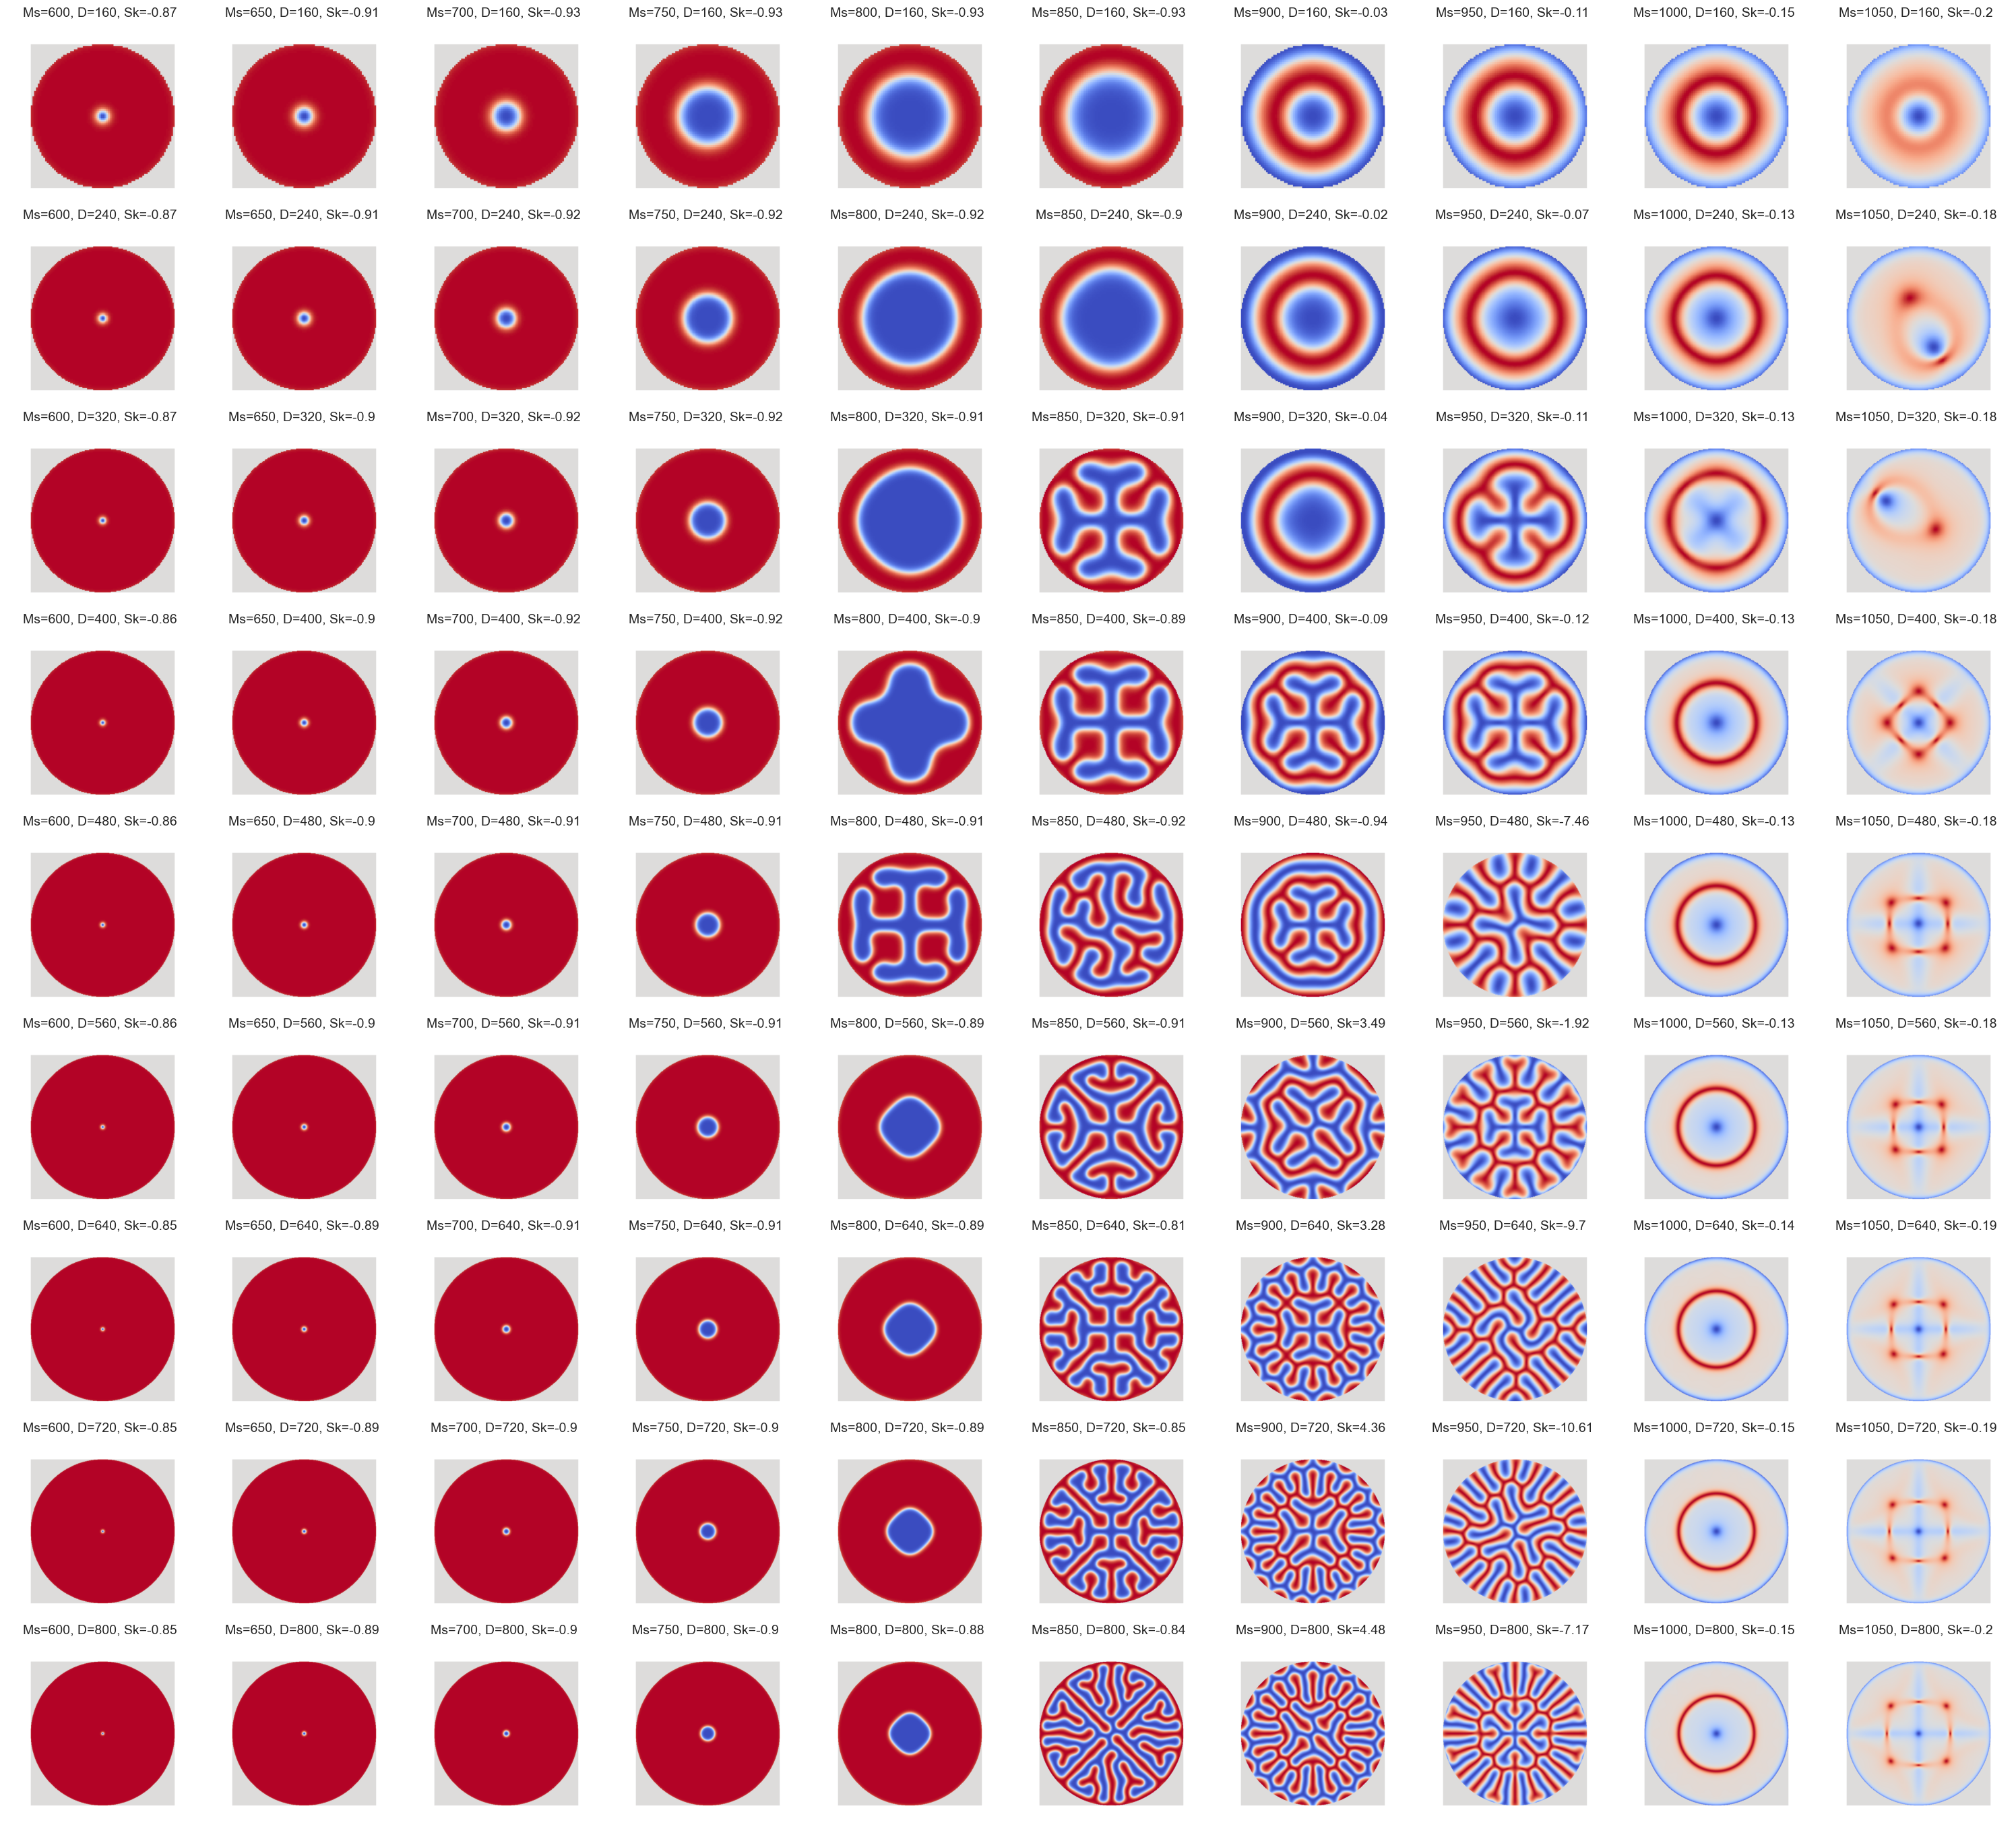

In [9]:
# PLOT PHASE DIAGRAM USING THE IMAGES

from PIL import Image
import re
import os

T = 0
dmi = 1.5
Ds = range(160, 880, 80)
Mss = range(600, 1100, 50)
images_path = f'../images/mumax_skyrmion_training/saf-skyrmion-images/dmi={dmi}/'
Sks = {}
data = []
for D in Ds:
    value = []
    for Ms in Mss:
        
        image_filename = f'bottomlayer_D={D}_Ms={Ms}_T={T}_dmi={dmi}'
        
        r = re.compile(f"{image_filename}_*")
        dir_list = os.listdir(images_path)
        
        image_file_path = list(filter(r.match, dir_list))[0]
        
        Sk = float(image_file_path.split('Sk=')[1].split('.')[0])/100
        Sks[(Ms,D)] = Sk
        pic = Image.open(images_path + image_file_path)
        #pix = np.array(pic.getdata())
        value.append(pic)
    data.append(value)
    
num_y = len(data)       # filas
num_x = len(data[0])    # columnas

fig, axes = plt.subplots(num_y, num_x, figsize=(3*num_x, 3*num_y))

for i in range(num_y):       # y → filas
    for j in range(num_x):   # x → columnas
        ax = axes[i, j]
        ax.imshow(data[i][j])   # cada entrada es PIL.Image
        ax.set_title(f"Ms={Mss[j]}, D={Ds[i]}, Sk={Sks[Mss[j],Ds[i]]}", fontsize=14)
        ax.axis("off")  # quitamos ejes
        
plt.subplots_adjust(wspace=0, hspace=0, left=0, bottom=0)
plt.tight_layout(pad=0)
#plt.show()
plt.savefig(f'../images/saf_skyrmion_phase_diagram_dmi={dmi}.png')

0.55


(0.0, 600.0)

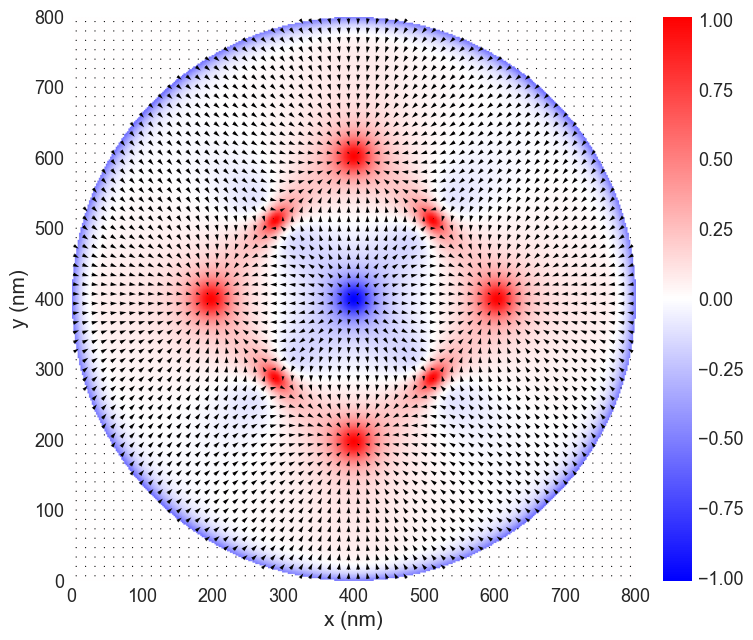

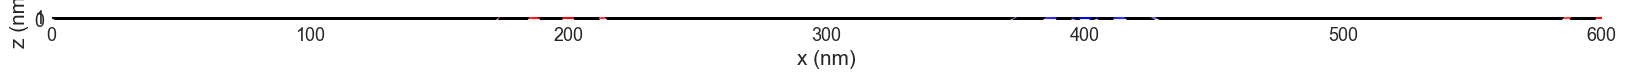

In [7]:
D = 800
Ms = 950

ovf_file = f'm_D={D}_Ms={Ms}_T=0_dmi=0.5.ovf'
read_field = discretisedfield.Field.from_file(f'../ovf_files/{ovf_file}')
#topological_charge = dft.topological_charge(read_field.sel(z=0.5e-9), method="berg-luescher")
#Sk = f'{topological_charge:.2f}'.replace('.','')
print(Sk)


px = 1/plt.rcParams['figure.dpi']
size = 800

fig, axs = plt.subplots(
figsize=(size*px, size*px),
    nrows=1,
    ncols=1
)

read_field.sel(z=0.5e-9).z.mpl.scalar(ax=axs, cmap='bwr',vmax=1.01,vmin=-1.01)
read_field.sel(z=0.5e-9).resample((60, 60)).mpl.vector(
        ax=axs, use_color=False, color="black"
)

fig, ax = plt.subplots(figsize=(20, 6))
read_field.sel("y").z.mpl.scalar(ax=ax, cmap="bwr", colorbar_label="z-component", colorbar=False)
read_field.sel("y").resample((60, 2)).mpl.vector(ax=ax, use_color=False, color="black")
ax.set_ylim(0, 1)
ax.set_xlim(0, 600)

#plt.axis('off')

In [29]:
saf_images_path = '../images/mumax_skyrmion_training/saf-skyrmion-images'

dmi=3
for D in Ds:
    for Ms in Mss:
        ovf_file = f'm_D={D}_Ms={Ms}_T=0_dmi={dmi}.ovf'
        read_field = discretisedfield.Field.from_file(f'../ovf_files/{ovf_file}')
        topological_charge = dft.topological_charge(read_field.sel(z=0.5e-9))
        Sk = f'{topological_charge:.2f}'.replace('.','')
        px = 1/plt.rcParams['figure.dpi']
        size = 800
        
        fig, axs = plt.subplots(
        figsize=(size*px, size*px),
            nrows=1,
            ncols=1
        )
        
        read_field.sel(z=0.5e-9).z.mpl.scalar(ax=axs, cmap='coolwarm', vmax=1, vmin=-1, colorbar=False)
        #read_field.sel(z=0.5e-9).resample((25, 25)).mpl.vector(
        #    ax=axs, use_color=False, color="black"
        #)
        plt.axis('off')

        filename = f'bottomlayer_D={D}_Ms={Ms}_T={T}_dmi={dmi}_Sk={Sk}.png'
        fig.savefig(
            f"{saf_images_path}/dmi={dmi}/{filename}",
            transparent="True",
            pad_inches=0
        )

        plt.close('all')

In [10]:
#saf_images_path = '../images/mumax_skyrmion_training/saf-skyrmion-images'

DMIs = [0.5,1,1.5,2,3]

table_columns = {
    'D': pd.Series(dtype=np.float64),
    'Ms': pd.Series(dtype=np.float64),
    'DMI': pd.Series(dtype=np.float64),
    'Sk': pd.Series(dtype=np.float64),
}

#new_table = pd.DataFrame(columns=list(table_columns.keys()))
new_table = pd.DataFrame(table_columns)

i=0
for dmi in DMIs:
    for D in Ds:
        for Ms in Mss:
            ovf_file = f'm_D={D}_Ms={Ms}_T=0_dmi={dmi}.ovf'
            read_field = discretisedfield.Field.from_file(f'../ovf_files/{ovf_file}')
            topological_charge = dft.topological_charge(read_field.sel(z=2.5e-9))
            new_table.loc[i] = [D,Ms,dmi,topological_charge]
            i += 1


In [12]:
new_table.to_csv('saf_skyrmion_training.csv')

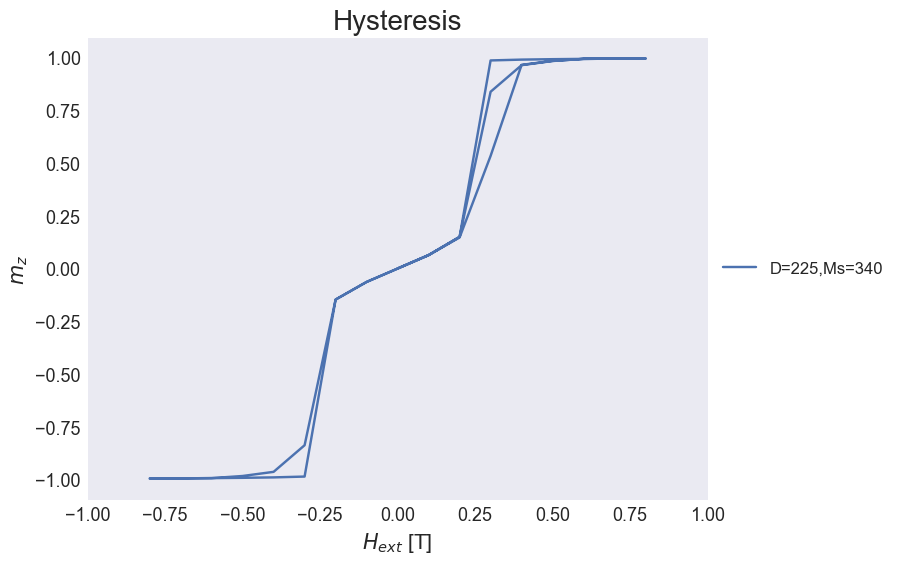

In [144]:
dmi = 1.0
data_path = '../data/data_hyst_batistel/'
filename = 'table_hyst_D={D}_Ms={Ms}_T={T}_dmi={dmi}_Ku=0.1.txt'
D = 225
Mss = range(600,1100,50)

Ms = 340
#for Ms in Mss:
df = pd.read_table(data_path + filename.format(
    D=D,
    Ms=Ms,
    dmi=dmi,
    T=0
))
mz = df['mz ()'] 
H = df['B_extz (T)']
plt.plot(H, mz, label=f'D={D},Ms={Ms}')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.title('Hysteresis')
plt.xlabel(r'$H_{ext}$ [T]')
plt.ylabel(r'$m_z$')
plt.xlim((-1,1))
plt.show()

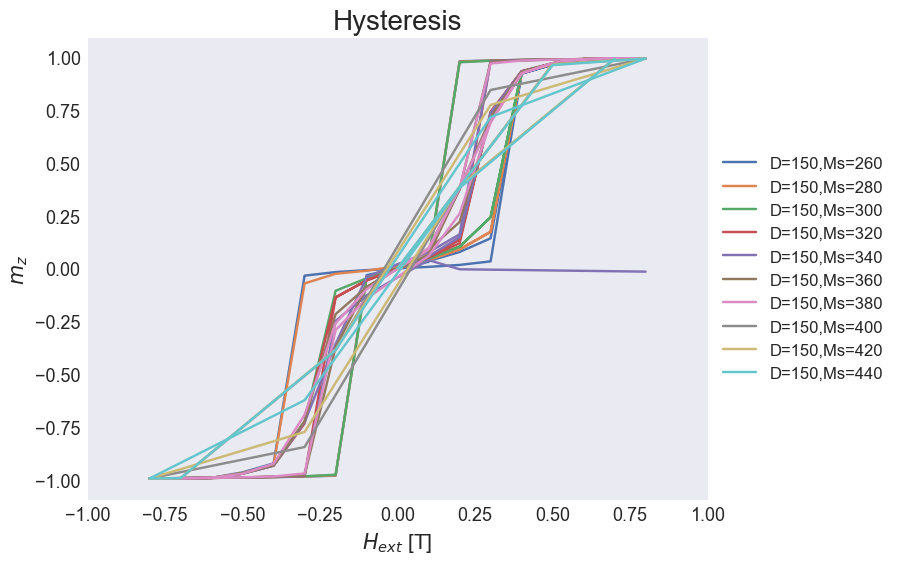

In [116]:
import time 

dmi = 1.0
data_path = '../data/data_hyst_batistel/'
filename = 'table_hyst_D={D}_Ms={Ms}_T={T}_dmi={dmi}_Ku=0.1.txt'
D = 150
Mss = range(260,460,20)

for Ms in Mss:
    df = pd.read_table(data_path + filename.format(
        D=D,
        Ms=Ms,
        dmi=dmi,
        T=0
    ))
    mz = df['mz ()'] 
    H = df['B_extz (T)']
    plt.plot(H, mz, label=f'D={D},Ms={Ms}')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.title('Hysteresis')
    plt.xlabel(r'$H_{ext}$ [T]')
    plt.ylabel(r'$m_z$')
    plt.xlim((-1,1))
    #plt.show()
    time.sleep(2)
plt.show()

In [154]:
import json

dmi = 1.0
T = 0
data_path = '../data/data_hyst_batistel/'

Ds = range(150, 825, 75)
Mss = range(260, 460, 20)

skyrmion_stability = {}

for D in Ds:
    for Ms in Mss:
    
        filename = f'topological_charge_hyst_D={D}_Ms={Ms}_T={T}_dmi={dmi}_Ku=0.1.json'
        with open(data_path+filename) as json_file:
            json_file = json.load(json_file)
    
        sk_values = json_file[f'({D},{Ms})']['s_k']
        s2k_values = json_file[f'({D},{Ms})']['s2_k']
        h_values = json_file[f'({D},{Ms})']['H']
        init = 0
        final = 34
        topological_charge_init = s2k_values[init]
        topological_charge_final = s2k_values[final]
        
        top_charge_diff = np.abs(topological_charge_final - topological_charge_init)
        
        if top_charge_diff < 1e-1 and abs(abs(sk_values[final])-1) < 2e-1:
        #if top_charge_diff < 1e-1:
            skyrmion_stability[(D,Ms)] = 'stable'
            print(f'Stable for D={D}, Ms={Ms}')
        else:
            skyrmion_stability[(D,Ms)] = 'metastable'
            print(f'Not stable for D={D}, Ms={Ms}')

Not stable for D=150, Ms=260
Stable for D=150, Ms=280
Stable for D=150, Ms=300
Not stable for D=150, Ms=320
Not stable for D=150, Ms=340
Not stable for D=150, Ms=360
Not stable for D=150, Ms=380
Not stable for D=150, Ms=400
Not stable for D=150, Ms=420
Not stable for D=150, Ms=440
Not stable for D=225, Ms=260
Stable for D=225, Ms=280
Stable for D=225, Ms=300
Stable for D=225, Ms=320
Stable for D=225, Ms=340
Stable for D=225, Ms=360
Not stable for D=225, Ms=380
Not stable for D=225, Ms=400
Not stable for D=225, Ms=420
Not stable for D=225, Ms=440
Stable for D=300, Ms=260
Stable for D=300, Ms=280
Not stable for D=300, Ms=300
Not stable for D=300, Ms=320
Not stable for D=300, Ms=340
Not stable for D=300, Ms=360
Not stable for D=300, Ms=380
Not stable for D=300, Ms=400
Not stable for D=300, Ms=420
Not stable for D=300, Ms=440
Not stable for D=375, Ms=260
Stable for D=375, Ms=280
Not stable for D=375, Ms=300
Not stable for D=375, Ms=320
Not stable for D=375, Ms=340
Not stable for D=375, Ms=

FileNotFoundError: [Errno 2] No such file or directory: '../data/data_hyst_batistel/topological_charge_hyst_D=750_Ms=260_T=0_dmi=1.0_Ku=0.1.json'

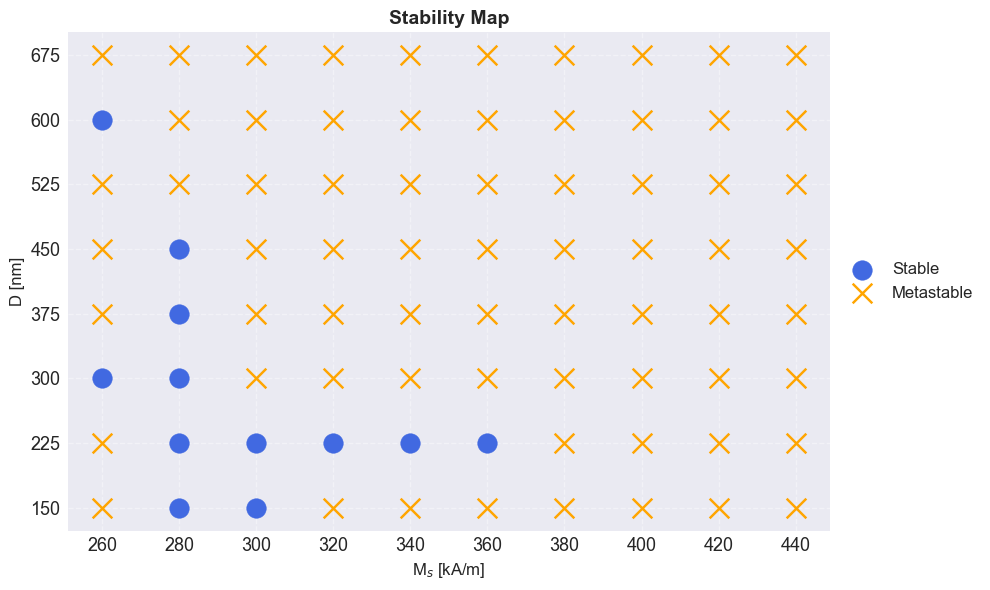

In [155]:
# Convert dictionary keys to arrays
D_values = np.array([k[0] for k in skyrmion_stability.keys()])
Ms_values = np.array([k[1] for k in skyrmion_stability.keys()])
states = np.array([v for v in skyrmion_stability.values()])

# Split data by state
stable_mask = states == 'stable'
metastable_mask = states == 'metastable'

# Create the figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot stable points (squares)
ax.scatter(
    Ms_values[stable_mask],
    D_values[stable_mask],
    marker='o',   # square
    color='royalblue',
    s=200,
    label='Stable'
)

# Plot metastable points (triangles)
ax.scatter(
    Ms_values[metastable_mask],
    D_values[metastable_mask],
    marker='x',   # triangle
    color='orange',
    s=200,
    label='Metastable'
)

# Labels and style
ax.set_ylabel('D [nm]', fontsize=12)
ax.set_xlabel('M$_s$ [kA/m]', fontsize=12)
ax.set_title('Stability Map', fontsize=14, weight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xticks(sorted(set(Ms_values)))
ax.set_yticks(sorted(set(D_values)))

plt.tight_layout()
plt.show()


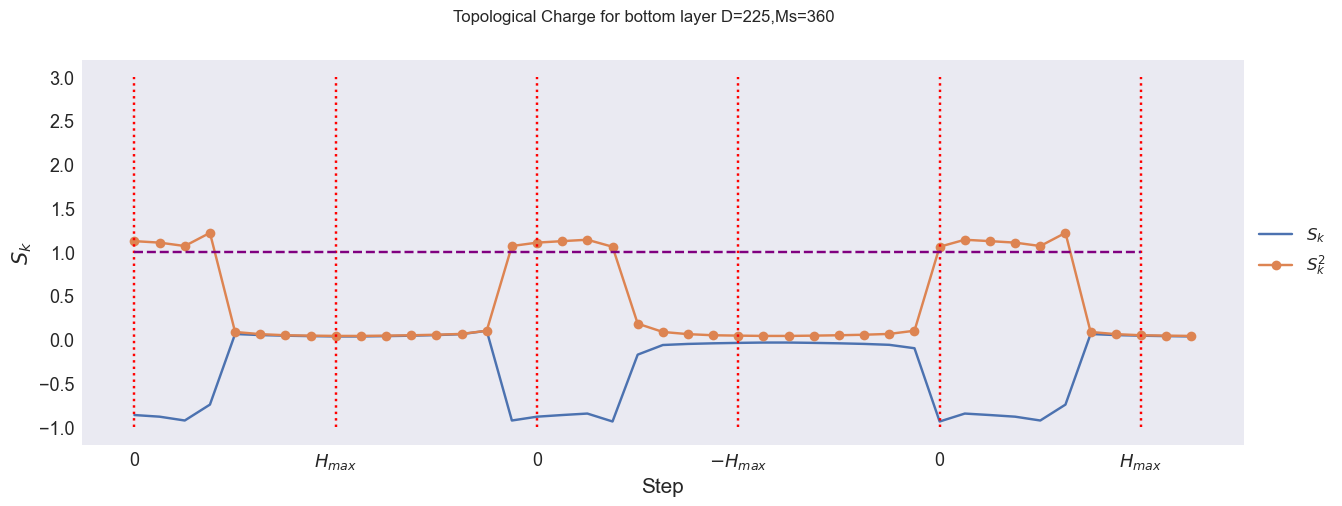

In [138]:
import json
import matplotlib.ticker as ticker

dmi = 1.0
D = 225
T = 0
Ms = 360
Ku = 0.1
data_path = '../data/data_hyst_batistel/'

filename = f'topological_charge_hyst_D={D}_Ms={Ms}_T={T}_dmi={dmi}_Ku={Ku}.json'
with open(data_path+filename) as json_file:
    json_file = json.load(json_file)
    
sk_values = json_file[f'({D},{Ms})']['s_k']
s2k_values = json_file[f'({D},{Ms})']['s2_k']
h_values =json_file[f'({D},{Ms})']['H']

#Mss = range(600,1100,50)

#for Ms in Mss:

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(sk_values, label=r'$S_k$')
ax.plot(s2k_values, label=r'$S^2_k$', marker='o')
for h in range(0,48,8):
    ax.vlines(x=h, ymin=-1, ymax=3, colors='red', linestyles='dotted')

ax.hlines(y=1, xmin=0, xmax=40, colors='purple', linestyles='dashed')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.suptitle(f'Topological Charge for bottom layer D={D},Ms={Ms}')
#plt.xlabel(r'$H_{ext}$ [T]')
ax.set_xlabel('Step')
ax.set_ylabel(r'$S_k$')
#ax.set_ylim((-2,2))

positions = [8*x for x in range(6)]
labels = ['0', r'$H_{max}$', '0', r'$-H_{max}$', '0', r'$H_{max}$']
ax.xaxis.set_major_locator(ticker.FixedLocator(positions))
ax.xaxis.set_major_formatter(ticker.FixedFormatter(labels))

plt.show()

In [87]:
A_x = 1e-11 #J/m
#Mss = range(600,1100,50) # kA/m
Mss = range(260,440,20) # kA/m
mu_0 = 1.256637e-6 # N.A^-2
Ku = 0.5e6 # J/m3

for Ms in Mss:
    l_magcrist = np.sqrt(A_x/Ku)*1e9
    l_magstatic = np.sqrt(2*A_x/(mu_0*1e6*(Ms**2)))*1e9
    l_char = 2.5*l_magstatic
    print(f'For Ms={Ms} kA/m we have \n\t l_ex,k={l_magcrist:.1f}nm\n\t l_ex,ms={l_magstatic:.1f}nm \n\t R_0={l_char:.1f} nm')

For Ms=260 kA/m we have 
	 l_ex,k=4.5nm
	 l_ex,ms=15.3nm 
	 R_0=38.4 nm
For Ms=280 kA/m we have 
	 l_ex,k=4.5nm
	 l_ex,ms=14.2nm 
	 R_0=35.6 nm
For Ms=300 kA/m we have 
	 l_ex,k=4.5nm
	 l_ex,ms=13.3nm 
	 R_0=33.2 nm
For Ms=320 kA/m we have 
	 l_ex,k=4.5nm
	 l_ex,ms=12.5nm 
	 R_0=31.2 nm
For Ms=340 kA/m we have 
	 l_ex,k=4.5nm
	 l_ex,ms=11.7nm 
	 R_0=29.3 nm
For Ms=360 kA/m we have 
	 l_ex,k=4.5nm
	 l_ex,ms=11.1nm 
	 R_0=27.7 nm
For Ms=380 kA/m we have 
	 l_ex,k=4.5nm
	 l_ex,ms=10.5nm 
	 R_0=26.2 nm
For Ms=400 kA/m we have 
	 l_ex,k=4.5nm
	 l_ex,ms=10.0nm 
	 R_0=24.9 nm
For Ms=420 kA/m we have 
	 l_ex,k=4.5nm
	 l_ex,ms=9.5nm 
	 R_0=23.7 nm
